## Sentiment Classification Model

*Models to use:*
- Classifier: distilbert-base-uncased

## Load Data

In [7]:
import pandas as pd
import torch
import pandas as pd

import pandas as pd

df = pd.read_csv(
    "/content/clean_reviews.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

#inspecting the dataset
df.head()

,name,reviews.rating,reviews.text,sentiment,clean_review
0,AmazonBasics AAA Performance Alkaline Batterie...,3,I order 3 of them and one of the item is bad q...,neutral,i order 3 of them and one of the item is bad q...
1,AmazonBasics AAA Performance Alkaline Batterie...,4,Bulk is always the less expensive way to go fo...,positive,bulk is always the less expensive way to go fo...
2,AmazonBasics AAA Performance Alkaline Batterie...,5,Well they are not Duracell but for the price i...,positive,well they are not duracell but for the price i...
3,AmazonBasics AAA Performance Alkaline Batterie...,5,Seem to work as well as name brand batteries a...,positive,seem to work as well as name brand batteries a...
4,AmazonBasics AAA Performance Alkaline Batterie...,5,These batteries are very long lasting the pric...,positive,these batteries are very long lasting the pric...


## Data Exploration
- Inspect dataset structure, size, and sentiment distribution.

In [8]:
df.shape
df["sentiment"].value_counts()
#Data is still heavily imbalanced, mostly positive

,count
sentiment,
positive,54893
neutral,2664
negative,2343


## Label Encoding
- Convert sentiment labels (text) into numerical values for the model.

In [9]:
#converting sentiment labels to numbers
label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

#applying the mapping to create the column "label"
df["label"] = df["sentiment"].map(label_map)

#showing both columns to verify the mapping work
df[["sentiment", "label"]].head()

,sentiment,label
0,neutral,1
1,positive,2
2,positive,2
3,positive,2
4,positive,2


## Train-Test Split
- Split data into training and testing sets.

In [10]:
from sklearn.model_selection import train_test_split

X = df["clean_review"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42,
stratify=y
)

print("Train size:", len(X_train))
print("test size:", len(X_test))


Train size: 47920
test size: 11980


##Baseline Model: TF-IDF + Logistic Regression

Before applying a transformer-based model, we use a simple baseline approach with TF-IDF and Logistic Regression.  
This helps us understand how much performance improvement we gain from more advanced models.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# Initiating TF-IDF vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#training Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

#predictions
y_pred_lr = lr_model.predict(X_test_tfidf)

#evaluation
accuracy = accuracy_score(y_test, y_pred_lr)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_lr, average="weighted")

print("TF-IDF Accuracy:", accuracy)
print("TF-IDF Precision:", precision)
print("TF-IDF Recall:", recall)
print("TF-IDF F1:", f1)

TF-IDF Accuracy: 0.9385642737896495
TF-IDF Precision: 0.9286327232231516
TF-IDF Recall: 0.9385642737896495
TF-IDF F1: 0.923605026274807


##Baseline Results

- TF-IDF achieves strong performance (~92% accuracy)
- This shows that simple models can already capture useful patterns in the data
- However, TF-IDF does not understand context or word relationships

## Tokenization
- Convert text into numerical format for the DistilBert model

In [12]:
from transformers import DistilBertTokenizer

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

sample = X_train.iloc[0]

tokens = tokenizer(
    sample,
    paddding="max_length",
    truncation=True,
    max_length=128
)

tokens

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': [101, 5310, 5379, 2130, 2005, 1037, 2512, 6627, 2666, 2711, 2066, 2026, 3566, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [13]:
#Taking only 100 reviews from training data
small_train = X_train.head(100).tolist()

#tokenizing those 100 reviews
small_encodings = tokenizer(
    small_train,
    padding=True,
    truncation=True,
    max_length=128
)
#showing what the tokenizer created
print(small_encodings.keys())

#showing how many reviews were processed
print(len(small_encodings["input_ids"]))

KeysView({'input_ids': [[101, 5310, 5379, 2130, 2005, 1037, 2512, 6627, 2666, 2711, 2066, 2026, 3566, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 3733, 2000, 2224, 3113, 4781, 2026, 4268, 2428, 5632, 2009, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [101, 2307, 13855, 2005, 1996, 3976, 1045, 2525, 2031, 1017, 8771, 2164, 1996, 10751, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [14]:
#function to tokenize in chunks (is faster and we avoid freezing)
def batch_tokenize(texts, tokenizer, batch_size=1000):
    input_ids = []
    attention_masks = []

    #loop through dataset in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        encodings = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128
        )
        #storing results
        input_ids.extend(encodings["input_ids"])
        attention_masks.extend(encodings["attention_mask"])

        print(f"Processed {i + len(batch)} / {len(texts)}")

    return {
        "input_ids": input_ids,
        "attention_mask": attention_masks
    }

#applying to full dataset
train_encodings = batch_tokenize(X_train.tolist(), tokenizer)
test_encodings = batch_tokenize(X_test.tolist(), tokenizer)

Processed 1000 / 47920
Processed 2000 / 47920
Processed 3000 / 47920
Processed 4000 / 47920
Processed 5000 / 47920
Processed 6000 / 47920
Processed 7000 / 47920
Processed 8000 / 47920
Processed 9000 / 47920
Processed 10000 / 47920
Processed 11000 / 47920
Processed 12000 / 47920
Processed 13000 / 47920
Processed 14000 / 47920
Processed 15000 / 47920
Processed 16000 / 47920
Processed 17000 / 47920
Processed 18000 / 47920
Processed 19000 / 47920
Processed 20000 / 47920
Processed 21000 / 47920
Processed 22000 / 47920
Processed 23000 / 47920
Processed 24000 / 47920
Processed 25000 / 47920
Processed 26000 / 47920
Processed 27000 / 47920
Processed 28000 / 47920
Processed 29000 / 47920
Processed 30000 / 47920
Processed 31000 / 47920
Processed 32000 / 47920
Processed 33000 / 47920
Processed 34000 / 47920
Processed 35000 / 47920
Processed 36000 / 47920
Processed 37000 / 47920
Processed 38000 / 47920
Processed 39000 / 47920
Processed 40000 / 47920
Processed 41000 / 47920
Processed 42000 / 47920
P

In [15]:
print(len(train_encodings["input_ids"]))
print(len(train_encodings["attention_mask"]))
print(len(test_encodings["input_ids"]))
print(len(test_encodings["attention_mask"]))

47920
47920
11980
11980


## Create PyTorch Dataset
- Prepare tokenized reviews and labels for model training.

In [16]:
#custom dataset class for our reviews
class ReviewDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        #storing tokenized text
        self.encodings = encodings
        #storing sentiment labels
        self.labels = labels

    def __getitem__(self, idx):
        #getting one review by index and convert to tensors
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels.iloc[idx])
        }

        return item

    def __len__(self):
        #returning num of reviews
        return len(self.labels)

#creating the dataset objects for train and test
train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)

#checking dataset sized
len(train_dataset), len(test_dataset)

(47920, 11980)

## Load Classification Model
- Load DistilBERT with 3 output labels: negative, neutral, positive.

In [17]:
from transformers import DistilBertForSequenceClassification

#load DistilBert and prepare for 3-class classification
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Training Setup
- Define how the model should train.

In [18]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="../outputs/results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_steps=100
)

## Trainer Setup
- Connect model, data, and training configuration.

In [19]:
from transformers import Trainer

#creating the trainer object
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

## Train Model
- Fine-tune DistilBERT on Amazon review sentiment labels.

In [20]:
trainer.train()

Step,Training Loss
100,0.736069
200,0.354345
300,0.358446
400,0.309108
500,0.322696
600,0.259311
700,0.257272
800,0.243479
900,0.303406
1000,0.256715


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5990, training_loss=0.22948201375334012, metrics={'train_runtime': 956.8752, 'train_samples_per_second': 50.08, 'train_steps_per_second': 6.26, 'total_flos': 1586987737067520.0, 'train_loss': 0.22948201375334012, 'epoch': 1.0})

## Model Evaluation
- Evaluating model performance on test data.

In [21]:
results = trainer.evaluate()

results

{'eval_loss': 0.17727962136268616,
 'eval_runtime': 53.7733,
 'eval_samples_per_second': 222.787,
 'eval_steps_per_second': 27.858,
 'epoch': 1.0}

## Detailed Evaluation Metrics
- Calculating accuracy, precision, recall, and F1-score.

In [22]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

#getting model predictions on test data
predictions = trainer.predict(test_dataset)

#converting prediction scores into predicted class labels
y_pred = predictions.predictions.argmax(axis=1)

#true labels
y_true = y_test.values

#calculating metrics
accuracy = accuracy_score(y_true, y_pred)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

#High accuracy is partly misleading, Model might be biased toward positive
#Dataset is heavily imbalanced with positive reviews

Accuracy: 0.9525041736227045
Precision: 0.9449637449439255
Recall: 0.9525041736227045
F1-score: 0.946624160114859


In [23]:
# Generate predictions first
predictions = trainer.predict(test_dataset)

# Convert logits to predicted labels
y_pred = predictions.predictions.argmax(axis=1)

# Create dataframe with wrong predictions
wrong_predictions = pd.DataFrame({
    "review": X_test.tolist(),
    "actual": y_test.tolist(),
    "predicted": y_pred
})

# Keep only wrong predictions
wrong_predictions = wrong_predictions[
    wrong_predictions["actual"] != wrong_predictions["predicted"]
]

# Convert numeric labels back to text
reverse_label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

wrong_predictions["actual"] = wrong_predictions["actual"].map(reverse_label_map)
wrong_predictions["predicted"] = wrong_predictions["predicted"].map(reverse_label_map)

# Show wrong reviews
wrong_predictions.head(20)

,review,actual,predicted
11,they don t last that long but since you get so...,positive,neutral
16,slow with limited application battery doesn t ...,negative,neutral
24,its a good tablet with very nice screen and fu...,neutral,positive
75,i use these for reading lights the kind you cl...,negative,positive
227,i do like the fire tablet but i feel that if i...,neutral,positive
229,it s a good tablet for the value downside is t...,neutral,positive
242,it was a cheap tablet just for kids to watch m...,negative,neutral
296,the tablet works fine it is responsive with go...,neutral,positive
325,i have been a kindle user for years and i expe...,negative,neutral
382,easy to use load books and to read in out door...,negative,positive


## Confusion Matrix
- Analyze where the model makes mistakes.

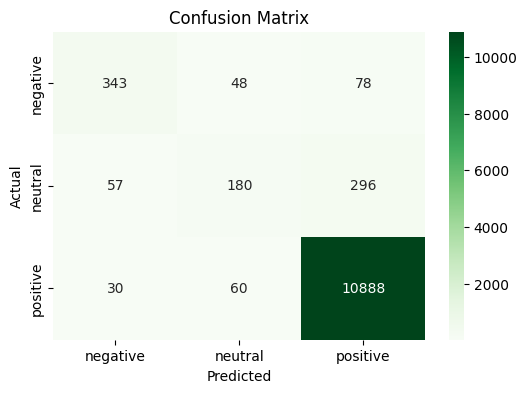

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["negative", "neutral", "positive"],
            yticklabels=["negative", "neutral", "positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Key Findings

- Model achieves high accuracy (~95%)
- Strong performance on positive reviews
- Weak performance on neutral reviews

## Limitations

- Dataset is imbalanced (mostly positive reviews)
- This imbalance biases the model towards predicting positive reviews

##Model Comparison

- TF-IDF baseline: ~92% accuracy, fast and simple
- DistilBERT: ~95% accuracy, better contextual understanding
- Transformer models outperform traditional methods on complex text data

##Classifier Performance Comparison

Comparison of the TF-IDF baseline and the DistilBERT classifier.

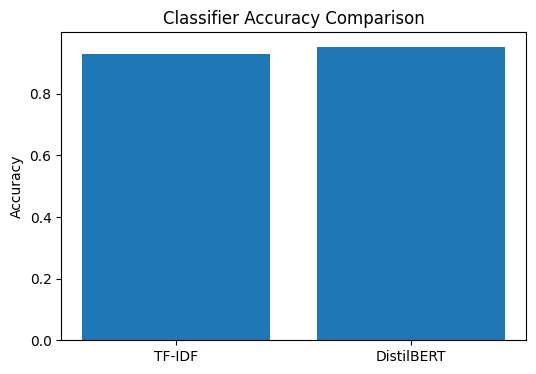

In [25]:
import matplotlib.pyplot as plt

#model names
models = ["TF-IDF", "DistilBERT"]

#accuracy scores
accuracy_scores = [0.9278, 0.9517]

#create chart
plt.figure(figsize=(6, 4))
plt.bar(models, accuracy_scores)

plt.ylabel("Accuracy")
plt.title("Classifier Accuracy Comparison")

plt.show()

DistilBERT slightly outperformed the TF-IDF baseline, showing that contextual transformer-based models provide better performance for review sentiment classification.